# 02 · Deferrable loads → scheduler `Job`s

**Goal.** Build the paper's **three** deferrable load types as lists of `Job`s, all on the
same UTC hourly grid the scheduler runs on:

| load | source | offline? |
|------|--------|----------|
| **HVAC** | NREL ResStock (committed MA parquet) | ✅ real, offline |
| **EV**   | Caltech ACN-Data (live API) | guarded → labelled demo |
| **AI**   | Alibaba GPU v2020 trace (download) | guarded → labelled demo |

Every `Job` has: `job_id, energy_kwh, earliest_start, deadline, power_kw`. Two derived
quantities matter:

- **duration** $=\lceil \text{energy}/\text{power}\rceil$ whole hours it must run;
- **slack** $=(\text{deadline}-\text{earliest\_start})-\text{duration}$ = spare hours the
  scheduler can slide the job around in. **No slack, no savings.**

In [1]:
# --- standard setup for every notebook in this paper ------------------------
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, "..")                 # find cals (in ../)
from dotenv import load_dotenv; load_dotenv("../.env")  # loads EIA_API_KEY if present
from cals import *          # FACTORS, carbon_intensity, Job, schedule, fifo_baseline, ...
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import nb_utils as U             # guarded data loaders + figure helper (see notebooks/nb_utils.py)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1 · HVAC (real NREL ResStock, offline)

Each hour of measured electric-HVAC energy becomes a one-hour job that may run
`flex_hours` earlier or later (a stand-in for thermal inertia / comfort slack). The HVAC
**deadline is an assigned knob** (`flex_hours`), not a hard physical constraint -- there is
no "must finish charging" moment like an EV has.

In [2]:
hvac_jobs, run_hours, hvac_df = U.load_hvac_jobs(flex_hours=6)   # bldg486202_MA_year
print("HVAC jobs:", len(hvac_jobs))
j = hvac_jobs[0]
print("example:", j.job_id, "| energy %.2f kWh | power %.2f kW | dur %dh | slack %dh"
      % (j.energy_kwh, j.power_kw, duration_h(j), slack_h(j)))

HVAC jobs: 8363
example: nrel_20190101T05 | energy 1.82 kWh | power 1.82 kW | dur 1h | slack 12h


## 2 · EV charging (guarded: Caltech ACN-Data)

`acn_to_jobs` maps each charging session to a job: energy = kWh delivered, window =
[plug-in, unplug], power = kWh / time-actually-charging. Real sessions need `acnportal` +
`ACN_API_TOKEN`; absent those we **skip gracefully** to a labelled demo set (same field
shape as the API, so the adapter is unchanged).

In [3]:
ev_jobs, ev_source = U.get_ev_jobs()
print("EV source:", ev_source, "| EV jobs:", len(ev_jobs))

EV: 10617 real sessions from https://ev.caltech.edu/api/v1/sessions/caltech


EV source: ACN-Data caltech 2019 (cached real pull) | EV jobs: 8507


## 3 · AI compute (guarded: Alibaba GPU v2020)

> **Download the real trace** (for anything reported):
> `cluster-trace-gpu-v2020` from
> <https://github.com/alibaba/clusterdata/tree/master/cluster-trace-gpu-v2020>,
> and drop the `pai_job_table` CSV into `../data/ai/`. With no CSV present we use a
> labelled **synthetic Alibaba-shaped** frame so this notebook runs offline.

A batch/training job runs on some GPUs for a while and must finish, but not at a specific
hour -- so it is deferrable. **Two assumptions must be swept** (they are modeling knobs, not
measurements):

- `gpu_power_kw` — per-GPU draw (A100/V100 ≈ 0.3–0.4 kW). Energy scales linearly with it.
- `flex_hours` — how deferrable a batch job is; it sets the slack. The trace has **no real
  deadline**, so like HVAC this is an **assigned knob**.

In [4]:
ai_jobs, ai_parsed, ai_source = U.get_ai_jobs(gpu_power_kw=0.4, flex_hours=6)
print("AI source:", ai_source, "| AI jobs:", len(ai_jobs))
ai_parsed.head(3)

AI source: Alibaba GPU v2020 (pai_task_table.csv) | AI jobs: 227529


,job_id,submit,duration_h,num_gpus
0,c936346f45eccd34bf748541,2019-07-02 04:07:15+00:00,0.725556,0.5
1,455c3dec270f4777ad67721c,2019-07-10 08:19:43+00:00,0.041389,1.0
2,ba64aa2f0feff18428923e92,2019-06-25 21:51:11+00:00,1.650556,0.5


## 4 · Slack distributions

Slack is what the scheduler has to work with. HVAC jobs get a fixed 2·`flex_hours` window;
EV slack is driven by real dwell (charge fast, sit plugged in); AI slack is
duration + `flex_hours`.

saved figure -> /Users/allanyu/RISE Projects/carbon-aware-load-scheduling/figures/02_slack_histograms.png


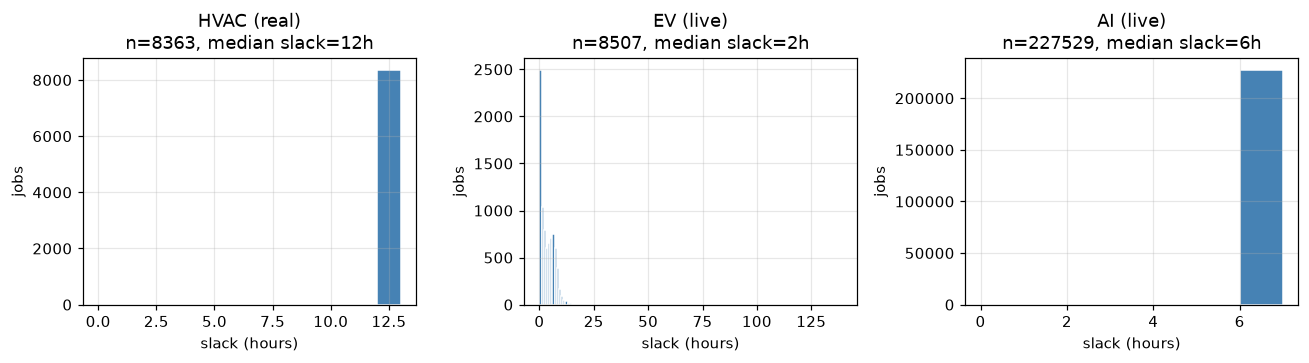

In [5]:
loads = {"HVAC (real)": hvac_jobs, "EV (%s)" % ("demo" if "DEMO" in ev_source else "live"): ev_jobs,
         "AI (%s)" % ("demo" if "DEMO" in ai_source else "live"): ai_jobs}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (name, jobs) in zip(axes, loads.items()):
    s = np.array([slack_h(j) for j in jobs])
    ax.hist(s, bins=range(0, int(s.max()) + 2), color="steelblue", edgecolor="white")
    ax.set_title("%s\nn=%d, median slack=%dh" % (name, len(jobs), int(np.median(s))))
    ax.set_xlabel("slack (hours)"); ax.set_ylabel("jobs")
fig.tight_layout(); U.savefig(fig, "02_slack_histograms.png"); plt.show()

In [6]:
# one small summary table for the paper
summary = pd.DataFrame({
    name: {"count": len(jobs),
           "median energy kWh": np.median([j.energy_kwh for j in jobs]).round(2),
           "median power kW": np.median([j.power_kw for j in jobs]).round(2),
           "median duration h": int(np.median([duration_h(j) for j in jobs])),
           "median slack h": int(np.median([slack_h(j) for j in jobs]))}
    for name, jobs in loads.items()}).T
display(summary)

,count,median energy kWh,median power kW,median duration h,median slack h
HVAC (real),8363.0,0.42,0.42,1.0,12.0
EV (live),8507.0,6.31,3.16,2.0,2.0
AI (live),227529.0,0.40,0.40,2.0,6.0
